In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



In [2]:
df = pd.read_csv(r"C:\Users\javier.sdiaz\Proyecto ML_2025\data\processed\datos_procesados.csv", sep=",")
df

,Temp_amb,Dir_viento,Vel_viento,Energia,Potencia,Oil_Temp,cosPhi,Frecuencia,Temp_int,Q,Año,Estacion,Rad_prom,HeatsinkTemp_prom,Idc_total,V_total,Minuto_sin,Hora_sin,Dia_sin,Mes_sin
0,11.346512,222.558422,2.611367,26.931747,0.0,26.079072,0.0,49.960499,20.329768,0.0,2022,1,0.0,17.075259,0.0,1146.307697,0.000000e+00,0.000000,0.781831,5.000000e-01
1,11.300000,223.087589,2.582713,0.000000,0.0,25.479083,0.0,49.959999,20.179770,0.0,2022,1,0.0,16.883596,0.0,1147.522942,1.000000e+00,0.000000,0.781831,5.000000e-01
2,11.306667,224.893609,2.640629,0.000000,0.0,24.879095,0.0,49.959999,20.029773,0.0,2022,1,0.0,16.691933,0.0,1150.385870,5.665539e-16,0.000000,0.781831,5.000000e-01
3,11.293333,223.534547,2.808005,0.000000,0.0,24.279182,0.0,49.959999,19.879776,0.0,2022,1,0.0,16.506316,0.0,1153.091744,-1.000000e+00,0.000000,0.781831,5.000000e-01
4,11.259853,230.927235,3.147298,0.000000,0.0,23.745968,0.0,49.960503,19.741495,0.0,2022,1,0.0,16.404334,0.0,1150.639247,0.000000e+00,0.258819,0.781831,5.000000e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105211,4.145149,223.663976,5.285611,740.750000,0.0,8.529718,0.0,50.000000,10.085310,0.0,2024,1,0.0,7.151938,0.0,1145.415732,-1.000000e+00,-0.500000,0.433884,-2.449294e-16
105212,4.245148,219.700928,5.490529,740.750000,0.0,8.329723,0.0,50.000000,10.117952,0.0,2024,1,0.0,7.165451,0.0,1145.233798,0.000000e+00,-0.258819,0.433884,-2.449294e-16
105213,4.376957,222.824833,5.048825,740.750000,0.0,8.329723,0.0,50.000000,10.117952,0.0,2024,1,0.0,7.165451,0.0,1145.233798,1.000000e+00,-0.258819,0.433884,-2.449294e-16
105214,4.493333,220.484426,4.876356,740.750000,0.0,8.329723,0.0,50.000000,10.117952,0.0,2024,1,0.0,7.165451,0.0,1145.233798,5.665539e-16,-0.258819,0.433884,-2.449294e-16


In [ ]:
X = df.drop(columns=['Energia'])  # Variables predictoras
y = df['Energia']  # Variable objetivo


In [4]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


In [5]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)


LinearRegression()

In [6]:
# Predicciones
y_pred_lr = lr_model.predict(X_val)

# Métricas de evaluación
def evaluar_modelo(y_test, y_pred, nombre):
    print(f"Evaluación del modelo: {nombre}")
    print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
    print(f"R²: {r2_score(y_test, y_pred):.2f}\n")

evaluar_modelo(y_val, y_pred_lr, "Regresión Lineal")



Evaluación del modelo: Regresión Lineal
MAE: 1843.13
RMSE: 2431.71
R²: 0.61



In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Definir la red neuronal
model = Sequential()
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))  # Capa de salida para regresión

# Compilar el modelo
model.compile(optimizer=Adam(learning_rate=0.01), loss='mse', metrics=['mae'])

# Definir EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',  # Monitorea la pérdida en validación
    patience=10,         # Si en 10 épocas no mejora, se detiene
    restore_best_weights=True  # Recupera los mejores pesos alcanzados
)

# Entrenar la red con EarlyStopping
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=16,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]  # Aquí aplicamos EarlyStopping
)



Epoch 1/200


c:\Users\javier.sdiaz\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5261/5261 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 9529382.0000 - mae: 2177.3076 - val_loss: 5251714.5000 - val_mae: 1485.9189
Epoch 2/200
5261/5261 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 5610599.0000 - mae: 1490.6804 - val_loss: 4618427.5000 - val_mae: 1306.5125
Epoch 3/200
5261/5261 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 5119070.5000 - mae: 1401.0168 - val_loss: 4346611.0000 - val_mae: 1190.9517
Epoch 4/200
5261/5261 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 4802973.0000 - mae: 1342.4111 - val_loss: 4071076.7500 - val_mae: 1232.4668
Epoch 5/200
5261/5261 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 4531439.0000 - mae: 1290.6250 - val_loss: 4413963.0000 - val_mae: 1290.9182
Epoch 6/200
5261/5261 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 4314377.5000 - mae: 1267.1188 - val_loss: 4165088.2500 - val_mae: 1327.1385
Epoch 7/200
5261/5261 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 4097458.2500 - mae: 1236.7681 - val_loss: 3549871.5000 - val_mae: 1164.8088
Epoch 8/200
5261/5261 ━━━━━━━━━━━━━━━

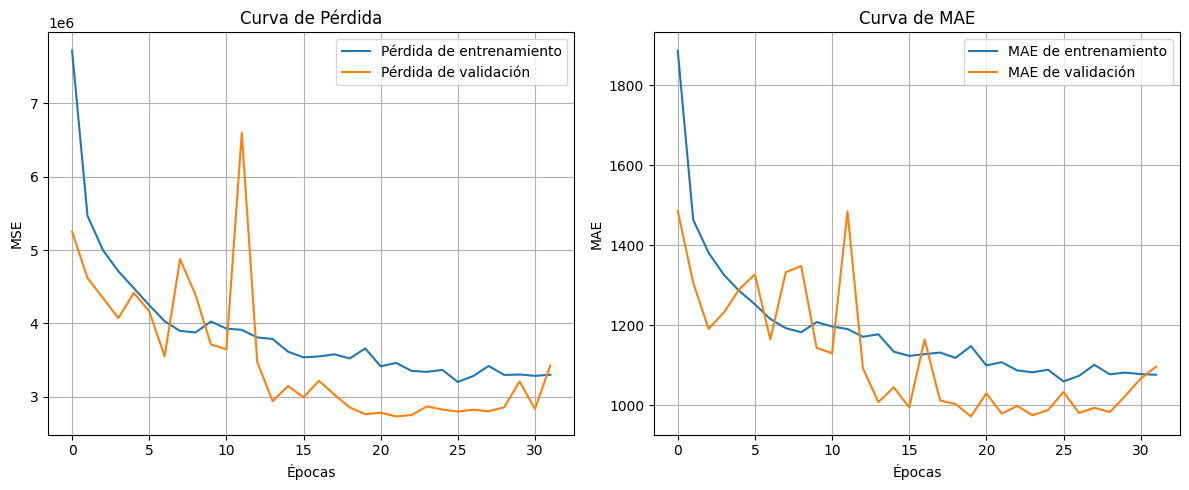

In [23]:
# Graficar pérdida (MSE)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de validación')
plt.xlabel('Épocas')
plt.ylabel('MSE')
plt.title('Curva de Pérdida')
plt.legend()
plt.grid(True)

# Graficar MAE (error absoluto medio)
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='MAE de entrenamiento')
plt.plot(history.history['val_mae'], label='MAE de validación')
plt.xlabel('Épocas')
plt.ylabel('MAE')
plt.title('Curva de MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [25]:
from tensorflow.keras.callbacks import ModelCheckpoint

# Guardar el mejor modelo
checkpoint = ModelCheckpoint(
    'Red_neuronal_energia.h5',      
    monitor='val_loss',       
    save_best_only=True,      
    verbose=1
)



